In [1]:
import numpy as np
import pandas as pd
from scipy.special import binom
import copy
import math
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
def convert_permutation_strings(permutation_series: pd.Series):
    # Determine dimensions of the result array
    population_length = permutation_series.shape[0]
    # Number of integers in the permutations (j*m)
    width = len(permutation_series[0].replace("  ", " ").replace("[ ", "").replace("[", "").replace("]", "").replace(" ]", "").replace("\n", "").split(" "))

    result_array = np.empty(shape=(population_length, width), dtype=int)
    for i in range(population_length):
        temp_array = np.array(permutation_series[i].replace("  ", " ").replace("[ ", "").replace("[", "").replace("]", "").replace(" ]", "").replace("\n", "").split(" "), dtype=int)
        result_array[i, :] = temp_array

    return result_array

def ecludian_distance_cross(permutation_matrix: np.ndarray):
    avg_sum = 0
    sum_counter = 0
    max_len = permutation_matrix.shape[0]
    for individual_comp1 in range(max_len):
        for individual_comp2 in range(individual_comp1+1, max_len):
            # calcualte euclidian distance
            avg_sum += np.sqrt(np.sum((permutation_matrix[individual_comp1, :] - permutation_matrix[individual_comp2, :])**2))
            sum_counter += 1

    print(binom(max_len, 2) - sum_counter)
    return avg_sum/sum_counter
        
class ListElement:
    def __init__(self, value, next):
        self.value = value
        self.next = next
    def nth(self, n):
        o = self
        i = 0
        while i < n and o.next is not None:
            o = o.next
            i += 1
        return o

def init(multiset):
    multiset.sort() # ensures proper non-increasing order
    h = ListElement(multiset[0], None)
    for item in multiset[1:]:
        h = ListElement(item, h)
    return h, h.nth(len(multiset) - 2), h.nth(len(multiset) - 1)

def visit(h):
    """Converts our bespoke linked list to a python list."""
    o = h
    l = []
    while o is not None:
        l.append(o.value)
        o = o.next
    return l

def permutations(multiset):
    """Generator providing all multiset permutations of a multiset."""
    h, i, j = init(multiset)
    yield visit(h)
    while j.next is not None or j.value < h.value:
        if j.next is not None and i.value >= j.next.value:
            s = j
        else:
            s = i
        t = s.next
        s.next = t.next
        t.next = h
        if t.value < h.value:
            i = t
        j = i.next
        h = t
        yield visit(h)



Functions for ranking permutations of multisets

In [3]:
def ranking_combination(comb_array: np.ndarray, n):
    # This funciton is used to find the rank of the combination given as input
    # Combination from set 1 to n
    # Look at each element subsequentially
    k = len(comb_array)
    binom_sum = 0
    for i in range(k):
        binom_sum += binom(n-comb_array[i], k - i)
    return binom(n, k) - 1 - binom_sum

def ranking_multiset(multi_array: np.ndarray, j: int, m:  int):
    multi_array = copy.deepcopy(multi_array)
    # Find combination of the first job number
    multi_prod = 1
    for k in range(j):
        # For each job k
        cur_combination = []
        cur_combination = np.where(multi_array == k)[0]

        #print(cur_combination)
        cur_set_size = cur_combination[-1]+1-k*m if cur_combination[-1]+1-k*m > 0 else 0
        cur_comb_rank = ranking_combination(cur_combination+1, cur_set_size*m)+1
        if cur_comb_rank > 0:
            multi_prod *= cur_comb_rank
        # remove job numbers
        multi_array = multi_array[multi_array > k]


    return multi_prod-1

In [4]:
from math import factorial
from collections import Counter

def multinomial_coefficient(freqs):
    """
    Computes the multinomial coefficient given a frequency dictionary.
    """
    n = sum(freqs.values())
    denominator = 1
    for count in freqs.values():
        denominator *= factorial(count)
    return factorial(n) // denominator

def rank_multiset_permutation(multiset, perm):
    """
    Computes the rank of a permutation in the sorted list of all permutations of a multiset.
    """
    rank = 0
    freqs = Counter(multiset)  # Count occurrences of each character
    
    for i, char in enumerate(perm):
        for smaller_char in sorted(freqs.keys()):
            if smaller_char < char:
                freqs[smaller_char] -= 1  # Temporarily reduce count
                rank += multinomial_coefficient(freqs)  # Add permutations possible
                freqs[smaller_char] += 1  # Restore count
        
        # Remove current character from frequency count
        freqs[char] -= 1
        if freqs[char] == 0:
            del freqs[char]
    
    return rank

# Example Usage:
multiset = "0011223344"
perm = "0110223344"
rank = rank_multiset_permutation(multiset, perm)
print(f"Rank of {perm}: {rank}")


Rank of 0110223344: 3150


Testing ranking function

In [227]:
ranking_multiset(np.array([0,1,1,0,2,2,3,3,4,4]), 5, 2)

2.0

In [248]:
multiset = [0,0,1,1,2,2,3,3,4,4,5,5]
permutation_list = []
ranks = []
counter = 0
if multiset != []:
    for permutation in permutations(multiset):
        permutation_list.append(permutation)
        ranks.append(rank_multiset_permutation("".join(np.array(multiset).astype(str)), "".join(np.array(permutation).astype(str))))
        counter += 1

print("Expected number of multiset permutations: " + str(math.factorial(5*2)//(math.factorial(2)**5)))
print("Number of multiset permutations: " + str(counter))
print("Unique ranks: " + str(len(set(ranks))))

KeyboardInterrupt: 

Testing the raning of combination algorithm

In [183]:
rank_list = []
n = 15
r = 7
for comb in combinations(range(n), r):
    rank_list.append(ranking_combination(np.array(comb)+1, n))

print(int(binom(n, r)))
print(len(set(rank_list)))

6435
6435


In [5]:
iteration_to_analyze = 198

hash_base_df = pd.read_csv("C:\\Users\\b-mor\\QGA_JSSP\\logdata_2\\Experiment_2_2025-02-07_17_11_03_736559\\population_dumps\\ft20_quantum_hash_base_encoding_dataset.csv")
positional_df = pd.read_csv("C:\\Users\\b-mor\\QGA_JSSP\\logdata_2\\Experiment_2_2025-02-07_00_30_41_481650\\population_dumps\\ft20_quantum_position_encoding_restricted_dataset.csv")

cur_permutation_array_hash = convert_permutation_strings(hash_base_df[hash_base_df["Iteration"] == iteration_to_analyze]["Permutation"].reset_index(drop=True))
cur_permutation_array_position = convert_permutation_strings(positional_df[positional_df["Iteration"] == iteration_to_analyze]["Permutation"].reset_index(drop=True))
del positional_df
del hash_base_df

hash_avg = ecludian_distance_cross(cur_permutation_array_hash)
position_avg = ecludian_distance_cross(cur_permutation_array_position)

print(f"Hash: {hash_avg}, Position: {position_avg}")

0.0
0.0
Hash: 81.42170977101118, Position: 77.61938363813074


Listing the ranks of each permutaiton found by the two methods

In [256]:
np.repeat(np.arange(2), 5)

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

In [7]:
def rank_each_permutation(cur_permutation_array_hash: np.ndarray, j: int, m: int):
    print(f"Starting ranking of {len(cur_permutation_array_hash)} permutaitons")
    res = []
    multiset = np.repeat(np.arange(j), m)
    for i, permutation in enumerate(cur_permutation_array_hash):
        print(f"{i}/{len(cur_permutation_array_hash)}")
        res.append(rank_multiset_permutation("".join(np.array(multiset).astype(str)), "".join(np.array(permutation).astype(str))))

    return res

Starting ranking of 200 permutaitons
Starting ranking of 200 permutaitons


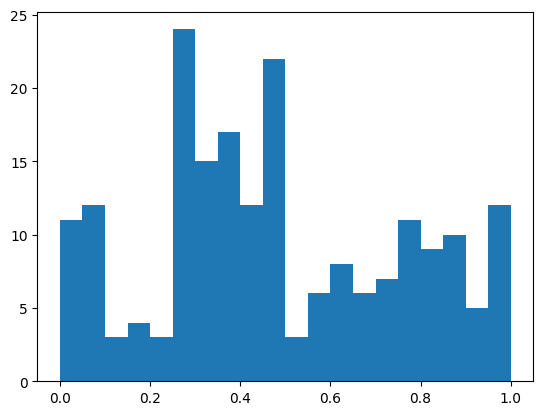

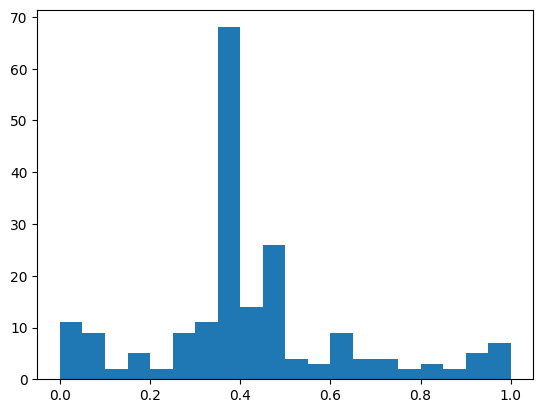

In [273]:
hash_rank_list = rank_each_permutation(cur_permutation_array_hash, 20, 5)
position_rank_list = rank_each_permutation(cur_permutation_array_position, 20, 5)

fig = plt.figure()
scaler_hash = MinMaxScaler()
scaled_list = scaler_hash.fit_transform(np.array(hash_rank_list).reshape(-1, 1))
plt.hist(scaled_list, bins=20)
plt.show()

fig = plt.figure()
scaler_hash = MinMaxScaler()
scaled_list = scaler_hash.fit_transform(np.array(position_rank_list).reshape(-1, 1))
plt.hist(scaled_list, bins=20)
plt.show()


In [270]:
scaled_list

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.]])

In [274]:
hash_base_df = pd.read_csv("C:\\Users\\b-mor\\QGA_JSSP\\logdata_2\\Experiment_2_2025-02-07_17_11_03_736559\\population_dumps\\ft20_quantum_hash_base_encoding_dataset.csv")
positional_df = pd.read_csv("C:\\Users\\b-mor\\QGA_JSSP\\logdata_2\\Experiment_2_2025-02-07_00_30_41_481650\\population_dumps\\ft20_quantum_position_encoding_restricted_dataset.csv")

cur_permutation_array_hash = convert_permutation_strings(hash_base_df["Permutation"].reset_index(drop=True))
cur_permutation_array_position = convert_permutation_strings(positional_df["Permutation"].reset_index(drop=True))

Starting ranking of 39800 permutaitons
0/39800
1/39800
2/39800
3/39800
4/39800
5/39800
6/39800
7/39800
8/39800
9/39800
10/39800
11/39800
12/39800
13/39800
14/39800
15/39800
16/39800
17/39800
18/39800
19/39800
20/39800
21/39800
22/39800
23/39800
24/39800
25/39800
26/39800
27/39800
28/39800
29/39800
30/39800
31/39800
32/39800
33/39800
34/39800
35/39800
36/39800
37/39800
38/39800
39/39800
40/39800
41/39800
42/39800
43/39800
44/39800
45/39800
46/39800
47/39800
48/39800
49/39800
50/39800
51/39800
52/39800
53/39800
54/39800
55/39800
56/39800
57/39800
58/39800
59/39800
60/39800
61/39800
62/39800
63/39800
64/39800
65/39800
66/39800
67/39800
68/39800
69/39800
70/39800
71/39800
72/39800
73/39800
74/39800
75/39800
76/39800
77/39800
78/39800
79/39800
80/39800
81/39800
82/39800
83/39800
84/39800
85/39800
86/39800
87/39800
88/39800
89/39800
90/39800
91/39800
92/39800
93/39800
94/39800
95/39800
96/39800
97/39800
98/39800
99/39800
100/39800
101/39800
102/39800
103/39800
104/39800
105/39800
106/39800
1

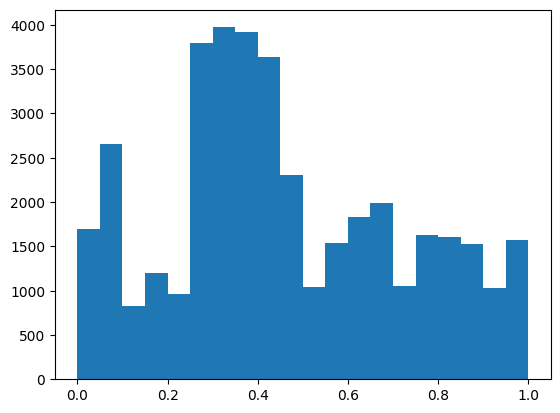

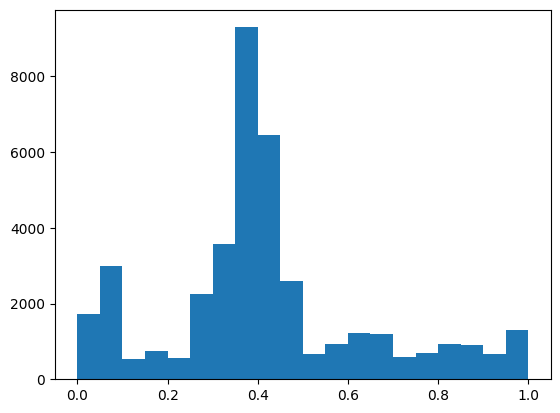

In [277]:
hash_rank_list = rank_each_permutation(cur_permutation_array_hash, 20, 5)
position_rank_list = rank_each_permutation(cur_permutation_array_position, 20, 5)

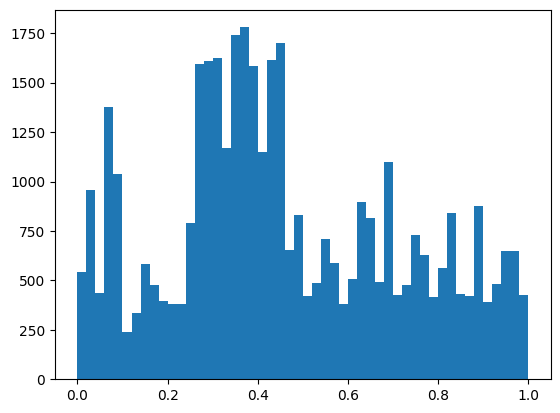

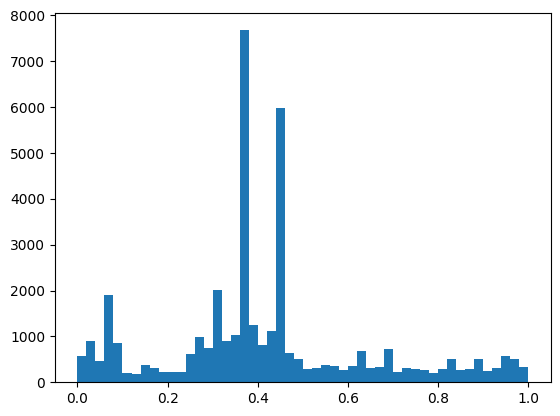

In [279]:
fig = plt.figure()
scaler_hash = MinMaxScaler()
scaled_list = scaler_hash.fit_transform(np.array(hash_rank_list).reshape(-1, 1))
plt.hist(scaled_list, bins=50)
plt.show()

fig = plt.figure()
scaler_hash = MinMaxScaler()
scaled_list = scaler_hash.fit_transform(np.array(position_rank_list).reshape(-1, 1))
plt.hist(scaled_list, bins=50)
plt.show()

In [280]:
len(hash_rank_list)

39800

In [282]:
len(set(hash_rank_list))

37820

In [283]:
len(set(position_rank_list))

35198

From this we can see that the difference clearly is that the position method ends up searchng more localy already during the first iteration.

Next experiment will be to see how much the permutation is changed by small changes in the bit strings

Starting ranking of 10000 permutaitons
0/10000
1/10000
2/10000
3/10000
4/10000
5/10000
6/10000
7/10000
8/10000
9/10000
10/10000
11/10000
12/10000
13/10000
14/10000
15/10000
16/10000
17/10000
18/10000
19/10000
20/10000
21/10000
22/10000
23/10000
24/10000
25/10000
26/10000
27/10000
28/10000
29/10000
30/10000
31/10000
32/10000
33/10000
34/10000
35/10000
36/10000
37/10000
38/10000
39/10000
40/10000
41/10000
42/10000
43/10000
44/10000
45/10000
46/10000
47/10000
48/10000
49/10000
50/10000
51/10000
52/10000
53/10000
54/10000
55/10000
56/10000
57/10000
58/10000
59/10000
60/10000
61/10000
62/10000
63/10000
64/10000
65/10000
66/10000
67/10000
68/10000
69/10000
70/10000
71/10000
72/10000
73/10000
74/10000
75/10000
76/10000
77/10000
78/10000
79/10000
80/10000
81/10000
82/10000
83/10000
84/10000
85/10000
86/10000
87/10000
88/10000
89/10000
90/10000
91/10000
92/10000
93/10000
94/10000
95/10000
96/10000
97/10000
98/10000
99/10000
100/10000
101/10000
102/10000
103/10000
104/10000
105/10000
106/10000
1

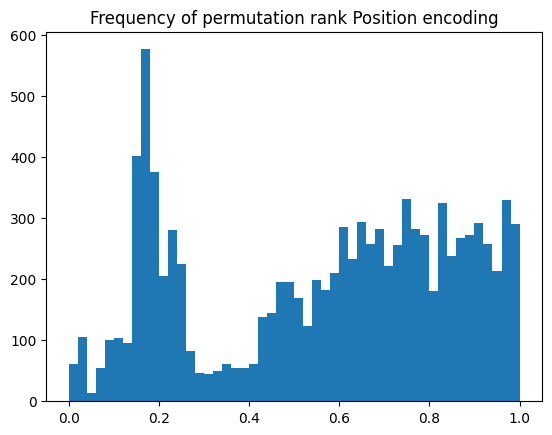

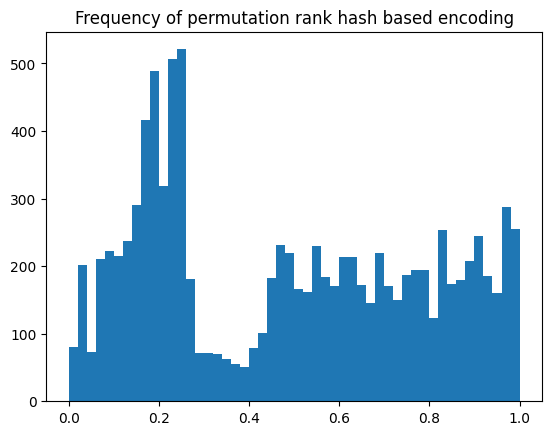

In [9]:
from individual import QChromosomeRepairPermutationEncoding, QChromosomePositionEncoding, QChromosomeHashPermutationEncoding, QChromosomeHashMultisetEncoding, QChromosomeHashMultisetImprovedEncoding
from omegaconf import DictConfig

j=12
m=10

test_permutation_5 = QChromosomeHashMultisetImprovedEncoding(j, m, DictConfig(content={"mutation_rate" : 0.1}), True)
test_permutation_2_1 = QChromosomePositionEncoding(j, m, DictConfig(content={"restrict_permutation" : False, "mutation_rate" : 0.1}), True)

sample_size = 10000
permutation_array_hash = np.empty(shape=(sample_size, j*m), dtype=int)
permutation_array_position = np.empty(shape=(sample_size, j*m), dtype=int)
for i in range(sample_size):
    test_permutation_5.measure()
    test_permutation_5.convert_permutation()
    permutation_array_hash[i, : ] = test_permutation_5.permutation
    test_permutation_2_1.measure()
    test_permutation_2_1.convert_permutation()
    permutation_array_position[i, : ] = test_permutation_2_1.permutation

hash_dist = rank_each_permutation(permutation_array_hash, j, m)
position_dist = rank_each_permutation(permutation_array_position, j, m)

fig = plt.figure()
scaler_hash = MinMaxScaler()
scaled_list = scaler_hash.fit_transform(np.array(hash_dist).reshape(-1, 1))
plt.hist(scaled_list, bins=50)
plt.title("Frequency of permutation rank Position encoding")
plt.show()

fig = plt.figure()
scaler_hash = MinMaxScaler()
scaled_list = scaler_hash.fit_transform(np.array(position_dist).reshape(-1, 1))
plt.hist(scaled_list, bins=50)
plt.title("Frequency of permutation rank hash based encoding")
plt.show()


In [3]:
5 % 10

5